```{thebe-init}
---
thebe: true
---
```

### Ações de correção para situações de atenção 

Abaixo, apresentamos um exemplo ilustrativo abordando a **situação 1** (pontos fora dos limites de controle), incluindo explicações, ferramentas de análise como **Diagrama de Causa e Efeito**, e a aplicação das **técnicas de CEP** e **PMBOK** para o gerenciamento e resolução do problema.

### Situação 1: **Pontos Fora do Limite de Controle**

#### Contexto:
Imagine que estamos monitorando a resistência do concreto em uma obra da construção civil. A resistência ideal do concreto é definida como 30 MPa, e o desvio padrão esperado é 2 MPa. Durante os testes diários, alguns pontos de medição começam a exceder os limites superiores ou inferiores de controle, indicando um possível problema no processo de produção do concreto.

**Exemplo de Código - Situação 1:**
Este código cria um gráfico que mostra a resistência do concreto em 30 amostras, com alguns pontos fora dos limites de controle definidos.



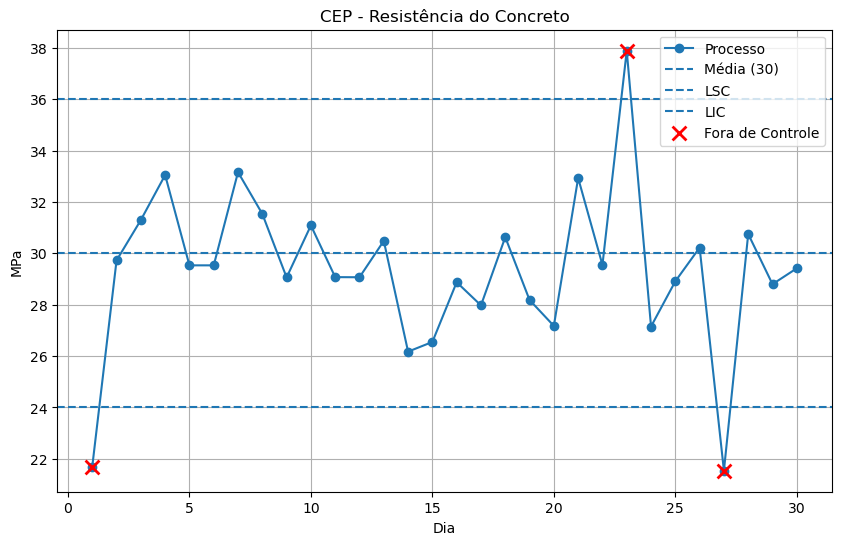

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# PARÂMETROS
# =========================

np.random.seed(42)  # Garante reprodutibilidade

n_amostras = 30
media = 30
desvio_padrao = 2

LC_superior = media + 3 * desvio_padrao
LC_inferior = media - 3 * desvio_padrao

# =========================
# DADOS SOB CONTROLE
# =========================

dados = np.random.normal(media, desvio_padrao, n_amostras)

# =========================
# CAUSAS ESPECIAIS ALEATÓRIAS
# =========================

prob_fora = 0.1
n_fora = max(1, int(prob_fora * n_amostras))

indices_fora = np.random.choice(n_amostras, size=n_fora, replace=False)

for i in indices_fora:
    if np.random.rand() > 0.5:
        dados[i] = np.random.normal(LC_superior + 2, 1)
    else:
        dados[i] = np.random.normal(LC_inferior - 2, 1)

# =========================
# DATAFRAME
# =========================

df = pd.DataFrame({
    'Dia': range(1, n_amostras + 1),
    'Resistencia': dados
})

# =========================
# DETECÇÃO DE FORA DE CONTROLE
# =========================

fora_controle = (df['Resistencia'] > LC_superior) | (df['Resistencia'] < LC_inferior)

# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(10, 6))

# Linha do processo (pontos normais)
plt.plot(df['Dia'], df['Resistencia'], marker='o', label='Processo')

# Linhas de controle
plt.axhline(media, linestyle='--', label=f'Média ({media})')
plt.axhline(LC_superior, linestyle='--', label='LSC')
plt.axhline(LC_inferior, linestyle='--', label='LIC')

# =========================
# DESTAQUE: FORA DE CONTROLE (VERMELHO COM "X")
# =========================

plt.scatter(
    df['Dia'][fora_controle],              # Eixo X (dias fora de controle)
    df['Resistencia'][fora_controle],      # Eixo Y (valores fora de controle)
    color='red',                           # Cor vermelha
    marker='x',                            # Marcador em forma de X
    s=100,                                 # Tamanho maior para destaque
    linewidths=2,                          # Espessura do "X"
    zorder=5,                              # Fica na frente dos outros pontos
    label='Fora de Controle'
)

# =========================
# FINALIZAÇÃO
# =========================

plt.title('CEP - Resistência do Concreto')
plt.xlabel('Dia')
plt.ylabel('MPa')
plt.legend()
plt.grid(True)

plt.show()

**Gráfico Gerado:**
- O gráfico mostra a evolução da resistência do concreto ao longo de 30 dias. Os limites de controle são definidos pela média ± 3 desvios padrão (±3σ).
- Os pontos destacados em vermelho, com marcador “X”, representam observações fora de controle.
- Esses pontos estão associados a causas especiais simuladas no processo, sendo gerados de forma aleatória, tanto em posição (dia) quanto em magnitude (valor).
- Valores acima do limite superior indicam possíveis desvios como excesso de dosagem, enquanto valores abaixo do limite inferior podem indicar falhas no processo, como problemas de mistura ou cura.

### **O que o Gerente de Projeto Deve Fazer?**

1. **Análise de Dados**
   - O gerente deve analisar a **distribuição dos dados** e verificar se a variabilidade observada é compatível com o comportamento esperado do processo.
   - Os pontos destacados fora dos limites de controle (±3σ) devem ser avaliados como possíveis **indícios de causas especiais**, e não apenas variação natural.
   - **Limites de Controle**: São definidos pela média do processo ± 3 desvios padrão. Pontos que ultrapassam esses limites indicam que o processo pode estar **fora de controle estatístico**, exigindo investigação.

2. **Causas Possíveis**
   - **Causas relacionadas ao processo**:
     - Controle inadequado da mistura (proporção de materiais, água/cimento).
     - Problemas no processo de cura do concreto.
     - Variação na qualidade dos insumos (cimento, agregados, água).
   - **Causas relacionadas à medição**:
     - Falha ou descalibração dos equipamentos de ensaio.
     - Procedimento de ensaio inadequado.
   - **Causas humanas**:
     - Erro operacional na dosagem ou execução.
     - Falhas no registro ou interpretação dos dados.

  

3. **Análise Estruturada das Causas**

   - A partir do gráfico de CEP apresentado anteriormente, os pontos fora de controle (destacados em vermelho com marcador “X”) indicam a presença de **causas especiais** no processo de produção do concreto.
   - Como essas ocorrências são simuladas de forma aleatória, o objetivo não é identificar um evento específico, mas sim **estruturar a análise das possíveis origens dessas variações**.

   - O **Diagrama de Causa e Efeito (Ishikawa)** permite organizar essas causas em categorias principais, facilitando a investigação.

   **Interpretação do Diagrama no Contexto do Gráfico:**

   - **Erro Humano**
     - Dosagem incorreta dos materiais.
     - Falhas operacionais durante mistura ou moldagem.
     - Registro incorreto dos resultados.

   - **Equipamento de Medição**
     - Prensa de ensaio descalibrada.
     - Procedimentos inconsistentes de ensaio.
     - Falhas na leitura dos resultados.

   - **Mistura de Concreto**
     - Relação água/cimento inadequada.
     - Variação nos agregados.
     - Tempo de mistura insuficiente.

   - **Controle de Qualidade**
     - Falta de padronização dos procedimentos.
     - Ausência de inspeções sistemáticas.
     - Não rastreabilidade dos lotes.

   - O efeito analisado, representado na extremidade direita do diagrama, é a **variação da resistência do concreto**, incluindo valores fora dos limites de controle observados no gráfico.

4. **Integração CEP + Ishikawa**

   - O gráfico de controle responde à pergunta:  
     → *“O processo está sob controle?”*

   - O diagrama de Ishikawa responde à pergunta:  
     → *“Por que o processo saiu de controle?”*

   - Dessa forma, o gerente de projeto deve:
     - Utilizar o **CEP para detecção** de anomalias.
     - Utilizar o **Ishikawa para investigação** das causas.
     - Priorizar ações corretivas com base nas causas mais prováveis.

5. **Ação Gerencial Esperada**

   - Investigar imediatamente os pontos fora de controle identificados.
   - Verificar histórico de produção nos dias correspondentes.
   - Auditar procedimentos de mistura, cura e ensaio.
   - Implementar ações corretivas e monitorar o processo com novos ciclos de CEP.

   - O objetivo final é retornar o processo a um estado de **controle estatístico**, reduzindo a ocorrência de causas especiais.

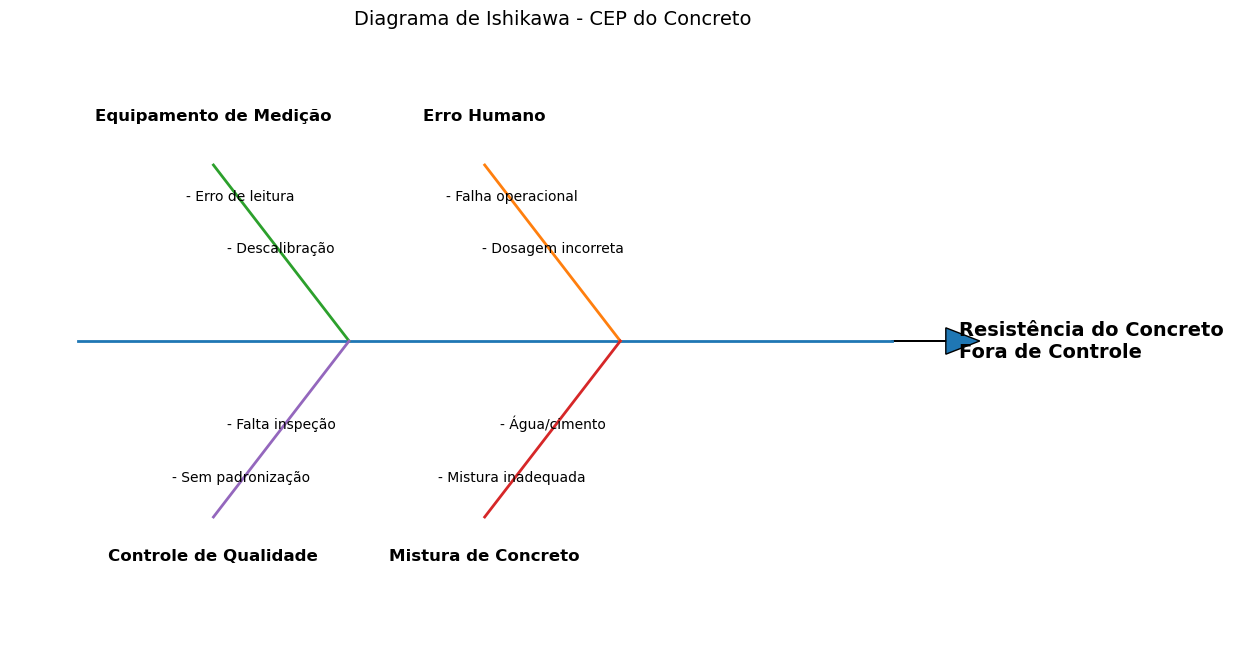

In [8]:
import matplotlib.pyplot as plt  # Biblioteca de plotagem

def plot_ishikawa_optimized():
    fig, ax = plt.subplots(figsize=(14, 8))  # Cria a figura

    # =========================
    # LINHA CENTRAL
    # =========================
    ax.plot([-12, 0], [0, 0], lw=2)  
    # Espinha principal horizontal

    ax.arrow(0, 0, 0.8, 0, head_width=0.3, head_length=0.5)  
    # Seta indicando o efeito

    # =========================
    # DEFINIÇÃO DAS CAUSAS (COORDENADAS ORGANIZADAS)
    # =========================

    # Cada causa agora tem um ponto base (x0, y0) e um ponto final (x1, y1)
    causas = [
        {"nome": "Erro Humano", "x": -4, "y": 0, "dx": -2, "dy": 2},
        {"nome": "Equipamento de Medição", "x": -8, "y": 0, "dx": -2, "dy": 2},
        {"nome": "Mistura de Concreto", "x": -4, "y": 0, "dx": -2, "dy": -2},
        {"nome": "Controle de Qualidade", "x": -8, "y": 0, "dx": -2, "dy": -2},
    ]

    # =========================
    # DESENHO DAS ESPINHAS E TEXTOS
    # =========================

    for c in causas:
        x0, y0 = c["x"], c["y"]              # Ponto inicial (linha central)
        x1, y1 = x0 + c["dx"], y0 + c["dy"]  # Ponto final da espinha

        ax.plot([x0, x1], [y0, y1], lw=2)  
        # Desenha a espinha

        # Ajuste fino da posição do texto (evita sobreposição)
        offset_y = 0.5 if y1 > 0 else -0.5  

        ax.text(x1, y1 + offset_y, c["nome"],
                fontsize=12, ha='center', weight='bold')
        # Coloca o rótulo da causa acima (ou abaixo) da linha

        # =========================
        # SUBCAUSAS (ALINHADAS COM A ESPINHA)
        # =========================

        if c["nome"] == "Erro Humano":
            sub = ["Dosagem incorreta", "Falha operacional"]

        elif c["nome"] == "Equipamento de Medição":
            sub = ["Descalibração", "Erro de leitura"]

        elif c["nome"] == "Mistura de Concreto":
            sub = ["Água/cimento", "Mistura inadequada"]

        else:
            sub = ["Falta inspeção", "Sem padronização"]

        # Distribui subcausas ao longo da espinha
        for i, s in enumerate(sub):
            fator = 0.5 + i * 0.3  # posição ao longo da linha

            xs = x0 + c["dx"] * fator
            ys = y0 + c["dy"] * fator

            ax.text(xs, ys, f"- {s}", fontsize=10, ha='center')
            # Posiciona subcausas sem sobrepor o título

    # =========================
    # EFEITO FINAL
    # =========================

    ax.text(1, 0, "Resistência do Concreto\nFora de Controle",
            fontsize=14, va='center', ha='left', weight='bold')
    # Texto do problema principal

    # =========================
    # AJUSTES VISUAIS
    # =========================

    ax.set_xlim([-13, 3])  # Limite horizontal
    ax.set_ylim([-3.5, 3.5])  # Limite vertical maior para evitar cortes

    ax.axis('off')  # Remove eixos

    plt.title("Diagrama de Ishikawa - CEP do Concreto", fontsize=14)

    plt.show()


# Execução
plot_ishikawa_optimized()

### **Ações Corretivas e Preventivas**

O gerente de projeto, ao identificar as causas da falha, deve aplicar as seguintes ações de correção e prevenção:

- **Correção Imediata**:
  - Verificar os pontos de **controle de qualidade** e **equipamentos de medição**. Garantir que as medições de resistência sejam precisas.
  - Se necessário, **ajustar a mistura de concreto** para garantir que a resistência esteja dentro dos limites esperados.

- **Ações Preventivas**:
  - **Treinamento contínuo** para a equipe sobre as práticas de controle de qualidade.
  - **Auditorias periódicas** nos processos de produção e medição para garantir que o processo esteja sempre sob controle.
  - **Melhoria contínua** no processo, utilizando dados de monitoramento para ajustar e otimizar os parâmetros de produção.

---




Após a análise com o **Diagrama de Causa e Efeito (Ishikawa)**, é possível aprofundar a investigação utilizando outras técnicas clássicas de controle de qualidade, como a **Análise de Pareto** e formulários estruturados de análise de causa.

### **Técnicas de Controle de Qualidade**

#### 1. **Análise de Pareto**

A **Análise de Pareto** baseia-se no princípio 80/20, segundo o qual uma pequena parcela das causas é responsável pela maior parte dos problemas. No contexto do gráfico de CEP apresentado, os pontos fora de controle representam ocorrências associadas a **causas especiais**, que podem ser classificadas conforme as categorias identificadas no diagrama de Ishikawa (erro humano, equipamento, mistura e controle de qualidade).

O objetivo da análise é identificar **quais categorias contribuem mais frequentemente** para as anomalias observadas no processo.

**Como aplicar no contexto do exemplo:**
- Classificar cada ocorrência fora de controle em uma categoria de causa (com base no Ishikawa).
- Contabilizar a frequência de cada tipo de causa.
- Ordenar as causas da mais frequente para a menos frequente.
- Calcular o percentual acumulado para identificar as causas prioritárias.

Dessa forma, o gerente de projeto pode concentrar esforços nas causas com maior impacto, otimizando ações corretivas e preventivas.

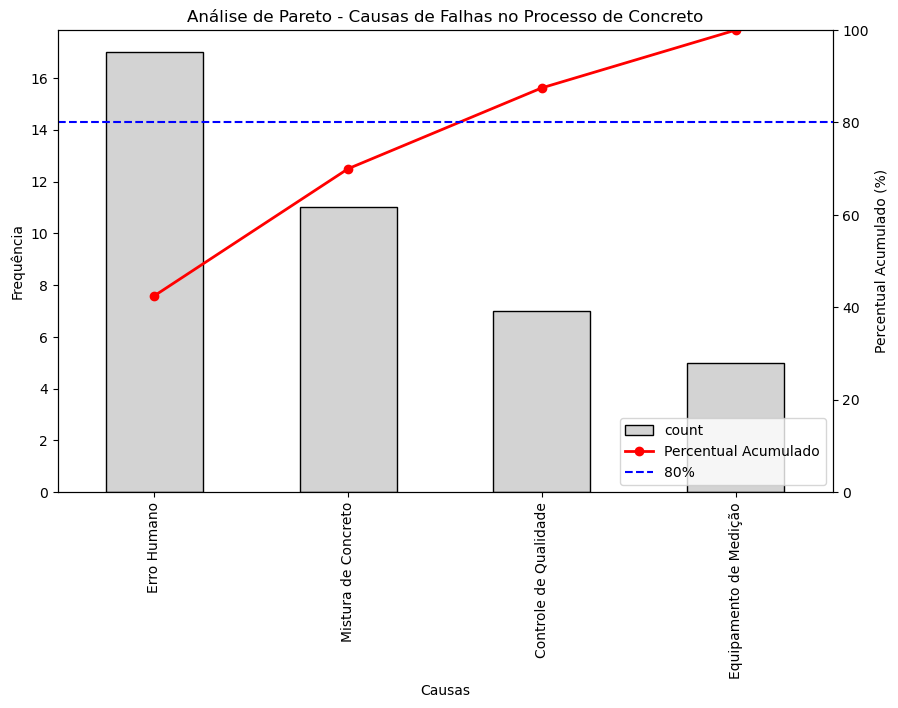

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# =========================
# DADOS SIMULADOS
# =========================

causas = [
    "Erro Humano",
    "Equipamento de Medição",
    "Mistura de Concreto",
    "Controle de Qualidade"
]

n_ocorrencias = 40

dados_causas = np.random.choice(
    causas,
    size=n_ocorrencias,
    p=[0.35, 0.15, 0.30, 0.20]
)

df = pd.DataFrame({'Causa': dados_causas})

frequencia = df['Causa'].value_counts().sort_values(ascending=False)
percentual = frequencia / frequencia.sum() * 100
percentual_acumulado = percentual.cumsum()

# =========================
# GRÁFICO DE PARETO
# =========================

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras (cor neutra)
frequencia.plot(
    kind='bar',
    ax=ax1,
    color='lightgray',          # cor distinta da linha
    edgecolor='black'           # contorno para melhor leitura
)

ax1.set_ylabel('Frequência')
ax1.set_xlabel('Causas')

# Linha acumulada (cor contrastante)
ax2 = ax1.twinx()
ax2.plot(
    percentual_acumulado.values,
    marker='o',
    linewidth=2,
    color='red',                # cor forte para destaque
    label='Percentual Acumulado'
)

ax2.set_ylabel('Percentual Acumulado (%)')
ax2.set_ylim(0, 100)

# Linha de referência 80%
ax2.axhline(
    80,
    linestyle='--',
    color='blue',               # terceira cor (referência)
    linewidth=1.5,
    label='80%'
)

# Legenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

plt.title('Análise de Pareto - Causas de Falhas no Processo de Concreto')

plt.show()

#### 2. **Formulários de Análise de Causa (FMEA - Failure Mode and Effect Analysis)**

O **FMEA** (Análise de Modos de Falha e Efeitos) é uma técnica estruturada de análise de risco utilizada para identificar possíveis modos de falha, suas causas e os impactos no produto ou processo. No contexto do controle de qualidade do concreto, o FMEA complementa o CEP e o Ishikawa ao permitir **priorizar riscos antes que ocorram falhas reais**.

**Aplicação no contexto do exemplo:**
- Os pontos fora de controle identificados no gráfico de CEP indicam possíveis falhas.
- O FMEA permite antecipar essas falhas, classificando-as por criticidade.
- As causas utilizadas podem ser diretamente derivadas do Diagrama de Ishikawa.

**Exemplo de FMEA para o processo de concreto:**

| **Modo de Falha**                | **Causa Potencial**              | **Efeito**                          | **Severidade (S)** | **Ocorrência (O)** | **Detecção (D)** | **RPN (S×O×D)** |
|----------------------------------|----------------------------------|-------------------------------------|--------------------|--------------------|------------------|-----------------|
| Resistência abaixo do esperado    | Proporção incorreta de materiais | Estrutura comprometida              | 9                  | 7                  | 4                | 252             |
| Resistência acima do esperado     | Mistura desbalanceada            | Fissuração / comportamento rígido   | 8                  | 5                  | 5                | 200             |
| Medição incorreta                | Equipamento descalibrado         | Decisões baseadas em dados inválidos| 7                  | 4                  | 6                | 168             |

**Cálculo do RPN (Risk Priority Number):**
- O **RPN = Severidade × Ocorrência × Detecção**
- Intervalo: 1 a 1000
- Quanto maior o RPN, maior a prioridade de ação

**Interpretação:**
- O modo de falha com maior RPN deve ser tratado primeiro
- Permite priorizar ações corretivas de forma objetiva
- Deve ser revisado continuamente conforme novos dados do CEP

---

#### 3. **Outras Técnicas de Controle de Processo (SPC)**

O **Statistical Process Control (SPC)** é uma abordagem abrangente que utiliza métodos estatísticos para monitorar e controlar processos. O gráfico de controle apresentado anteriormente é uma das principais ferramentas do SPC.

No caso do concreto, o SPC permite:
- Monitorar a resistência ao longo do tempo
- Detectar causas especiais (fora de controle)
- Manter o processo estável e previsível

---

#### **Índice de Capacidade do Processo (CPK)**

O **CPK** mede a capacidade do processo em atender aos limites de especificação definidos pelo cliente.

**Fórmula:**

\[
CPK = \min \left( \frac{USL - \mu}{3\sigma}, \frac{\mu - LSL}{3\sigma} \right)
\]

Onde:
- **USL** = Limite Superior de Especificação  
- **LSL** = Limite Inferior de Especificação  
- **μ** = média do processo  
- **σ** = desvio padrão  

**Interpretação:**
- **CPK < 1,0** → Processo incapaz  
- **CPK ≈ 1,0** → Processo marginal  
- **CPK ≥ 1,33** → Processo capaz  
- **CPK ≥ 1,67** → Processo altamente capaz  

**Observação importante:**
- O CPK só é válido quando o processo está **estatisticamente sob controle** (verificado pelo CEP).
- Caso existam muitos pontos fora de controle (como no exemplo com causas especiais), o cálculo do CPK pode não ser confiável.

---

### **Integração das Técnicas**

- **CEP** → Detecta quando o processo sai de controle  
- **Ishikawa** → Estrutura possíveis causas  
- **Pareto** → Prioriza as causas mais frequentes  
- **FMEA** → Prioriza os riscos mais críticos  
- **CPK** → Avalia a capacidade do processo  

Essas ferramentas devem ser utilizadas de forma integrada para garantir qualidade e estabilidade no processo de produção do concreto.

> ## **CPK - Exemplo**

In [12]:
# Parâmetros do processo (já estabilizado via CEP)
media = 30
desvio_padrao = 2

# Limites de especificação (engenharia)
LSL = 25
USL = 40

# Cálculo do CPK
cpk = min(
    (USL - media) / (3 * desvio_padrao),
    (media - LSL) / (3 * desvio_padrao)
)

print("CPK:", round(cpk, 3))

CPK: 0.833


> ### **Interpretação do CPK no Exemplo**
>
> No cálculo apresentado, foram utilizados **limites de especificação (LSL e USL)**, que representam os requisitos definidos pelo projeto ou pelo cliente — e não os limites de controle do CEP.
>
> - **LSL (25 MPa)**: resistência mínima aceitável  
> - **USL (40 MPa)**: resistência máxima tolerada  
>
> O **CPK** avalia o quanto o processo está centrado e ajustado dentro desses limites. Ele considera o pior caso (lado mais crítico):
>
> \[
> CPK = \min \left( \frac{USL - \mu}{3\sigma}, \frac{\mu - LSL}{3\sigma} \right)
> \]
>
> No exemplo:
>
> - Distância até o limite superior: \( (40 - 30) / 6 = 1{,}67 \)  
> - Distância até o limite inferior: \( (30 - 25) / 6 = 0{,}83 \)  
>
> Assim:
>
> \[
> CPK = 0{,}83
> \]
>
> **Interpretação:**
> - O processo está **mais próximo do limite inferior (LSL)**  
> - Existe maior risco de produzir concreto com resistência abaixo do mínimo exigido  
> - Portanto, o processo é considerado **não capaz (CPK < 1,33)**, mesmo estando estável  
>
> **Conclusão:**  
> O problema não está apenas na variabilidade, mas no **deslocamento da média em direção ao limite inferior**, sendo necessário ajustar o processo (centralizar ou reduzir variabilidade).

### **Ações de Correção e Melhoria**

Com base nas análises realizadas (CEP, Ishikawa, Pareto e FMEA), o gerente de projeto deve adotar uma abordagem estruturada para correção e melhoria do processo:

1. **Identificação das Causas Prioritárias**
   - Utilizar a **Análise de Pareto** para determinar quais categorias de causa (ex.: mistura de concreto, erro humano) concentram a maior parte das ocorrências fora de controle.
   - Priorizar intervenções nas causas com maior impacto quantitativo no processo.

2. **Investigação e Tratamento de Causas Especiais**
   - A partir do **CEP**, analisar especificamente os pontos fora de controle identificados.
   - Utilizar o **Diagrama de Ishikawa** para estruturar a investigação e evitar análises superficiais.
   - Confirmar as causas com evidências operacionais (registros de produção, ensaios, condições de execução).

3. **Implementação de Ações Corretivas**
   - Corrigir diretamente as causas identificadas:
     - Ajuste da dosagem e controle da relação água/cimento.
     - Padronização do processo de mistura e cura.
     - Calibração de equipamentos de ensaio.
     - Treinamento operacional da equipe.
   - Garantir que as ações sejam documentadas e rastreáveis.

4. **Prevenção e Gestão de Riscos**
   - Aplicar o **FMEA** para antecipar falhas potenciais antes que ocorram.
   - Priorizar ações com base no **RPN (Risk Priority Number)**.
   - Implementar controles preventivos (checklists, planos de inspeção, validação de insumos).

5. **Monitoramento Contínuo do Processo**
   - Utilizar **CEP (SPC)** para acompanhar a estabilidade do processo ao longo do tempo.
   - Atualizar continuamente os gráficos de controle e verificar a ausência de causas especiais.
   - Somente após a estabilização, avaliar a **capacidade do processo (CPK)**.

6. **Avaliação da Capacidade do Processo**
   - Calcular o **CPK** apenas quando o processo estiver sob controle estatístico.
   - Verificar se o processo atende aos limites de especificação do cliente.
   - Caso o CPK seja insuficiente, promover melhorias estruturais no processo (não apenas correções pontuais).

---

### **Conclusão**

A integração das ferramentas de qualidade permite uma abordagem completa para gestão do processo:

- **CEP** → Detecta desvios e instabilidade  
- **Ishikawa** → Estrutura a análise de causas  
- **Pareto** → Prioriza esforços  
- **FMEA** → Antecipação e gestão de riscos  
- **CPK** → Avalia a capacidade do processo  

Ao aplicar essas técnicas de forma integrada, o gerente de projeto consegue não apenas corrigir falhas pontuais, mas também **aumentar a robustez, previsibilidade e capacidade do processo**, assegurando que a resistência do concreto atenda consistentemente aos requisitos de projeto e às condições de segurança exigidas.